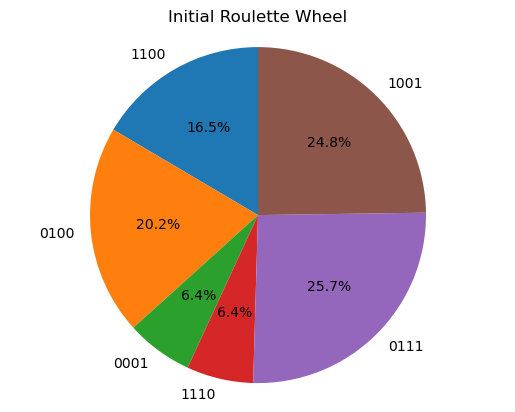

Initial fitness values: [36, 44, 14, 14, 56, 54]
Selection probabilities: [0.1651376146788991, 0.2018348623853211, 0.06422018348623854, 0.06422018348623854, 0.25688073394495414, 0.24770642201834864]


In [40]:
import numpy as np
import matplotlib.pyplot as plt

#part A
#chromosome population
chromosomes = ["1100", "0100", "0001", "1110", "0111", "1001"]

#fitness function: f(x)=15x - x^2
def fitness(x):
    return 15 * x - x**2

#binary strings to decimal
decimal_values = [int(chromosome, 2) for chromosome in chromosomes]

#calc fitness values
fitness_values = [fitness(x) for x in decimal_values]

#calc probabilities
total_fitness = sum(fitness_values)
probabilities = [f / total_fitness for f in fitness_values]

#draw the Roulette Wheel
def draw_roulette_wheel(labels, sizes, title):
    fig, ax = plt.subplots()
    ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
    ax.axis('equal')  # Equal aspect ratio ensures the pie is drawn as a circle.
    plt.title(title)
    plt.show()

#plotting the initial roulette wheel
draw_roulette_wheel(chromosomes, probabilities, "Initial Roulette Wheel")

#output
print("Initial fitness values:", fitness_values)
print("Selection probabilities:", probabilities)


In [42]:
# part B
#1point crossover function
def one_point_crossover(parent1, parent2, point):
    return parent1[:point] + parent2[point:], parent2[:point] + parent1[point:]

#parents
parent1 = chromosomes[5]  # 6th chromosome: "1001"
parent2 = chromosomes[1]  # 2nd chromosome: "0100"

#crossover at 3rd pos
crossover_point = 3
child1, child2 = one_point_crossover(parent1, parent2, crossover_point)

#updated population
chromosomes[5] = child1
chromosomes[1] = child2

#recalc fitness values
decimal_values = [int(chromosome, 2) for chromosome in chromosomes]
fitness_values = [fitness(x) for x in decimal_values]

#Output
print(f"Crossover between 6th string '{parent1}' and 2nd string '{parent2}' at 3rd position:")
print(f"Offspring1: {child1}")
print(f"Offspring2: {child2}")
print("Updated population after crossover:", chromosomes)
print("Updated fitness values after crossover:", fitness_values)


Crossover between 6th string '1001' and 2nd string '0100' at 3rd position:
Offspring1: 1000
Offspring2: 0101
Updated population after crossover: ['1100', '0101', '0001', '1110', '0111', '1000']
Updated fitness values after crossover: [36, 50, 14, 14, 56, 56]


In [44]:
# part C
# mutation func
def mutate(chromosome, positions):
    mutated = list(chromosome)
    for pos in positions:
        mutated[pos] = '1' if mutated[pos] == '0' else '0'
    return ''.join(mutated)

#mutate 1st and 5th chromosomes at 2nd and 3rd positions
positions = [1, 2]
chromosomes[0] = mutate(chromosomes[0], positions)  # 1st chromosome
chromosomes[4] = mutate(chromosomes[4], positions)  # 5th chromosome

# recalculate fitness values after mutation
decimal_values = [int(chromosome, 2) for chromosome in chromosomes]
fitness_values = [fitness(x) for x in decimal_values]

# Output results
print(f"Mutation in 1st string and 5th string at positions {positions}:")
print("Updated population after mutation:", chromosomes)
print("Updated fitness values after mutation:", fitness_values)


Mutation in 1st string and 5th string at positions [1, 2]:
Updated population after mutation: ['1010', '0101', '0001', '1110', '0001', '1000']
Updated fitness values after mutation: [50, 50, 14, 14, 14, 56]


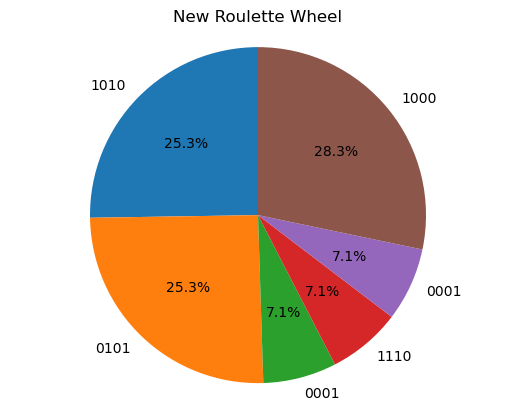

New selection probabilities: [0.25252525252525254, 0.25252525252525254, 0.0707070707070707, 0.0707070707070707, 0.0707070707070707, 0.2828282828282828]
Improvement in fitness percentage: -9.174311926605505


In [46]:
# part D
# calc new probabilities
total_fitness_new = sum(fitness_values)
probabilities_new = [f / total_fitness_new for f in fitness_values]

# draw the new Roulette Wheel
draw_roulette_wheel(chromosomes, probabilities_new, "New Roulette Wheel")

#calc fitness improvement
fitness_improvement = ((total_fitness_new - total_fitness) / total_fitness) * 100

#results
print("New selection probabilities:", probabilities_new)
print("Improvement in fitness percentage:", fitness_improvement)
